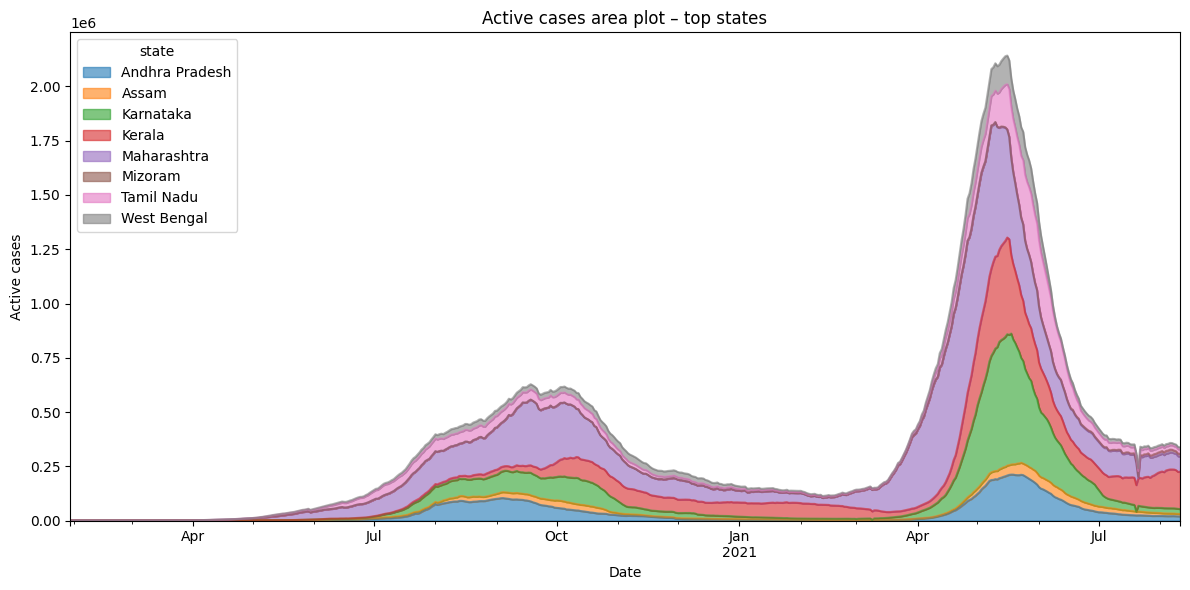

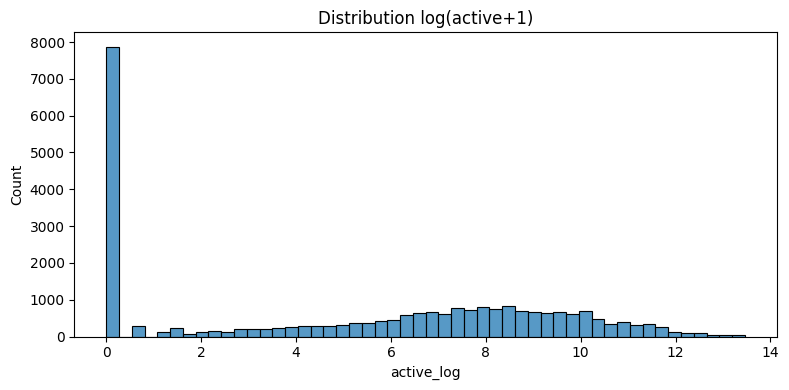

In [6]:
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# --- Paths ---
PANEL_CSV = Path(r"C:\Users\dedee\Downloads\epidemic-project\data_curated\panel_state_daily.csv")
FIGS_DIR = Path(r"C:\Users\dedee\Downloads\epidemic-project\figs")
FIGS_DIR.mkdir(parents=True, exist_ok=True)  # create folder if it doesn't exist

# --- Load data ---
panel = pd.read_csv(PANEL_CSV, parse_dates=['Date'])
states = panel['state'].unique()

# --- Plot top states active cases ---

top_states_panel = panel[panel['state'].isin(top_states)]
pivot = top_states_panel.pivot_table(index='Date', columns='state', values='active', aggfunc='sum')
pivot.plot.area(figsize=(12,6), alpha=0.6)
plt.title("Active cases area plot – top states")
plt.ylabel("Active cases")
plt.tight_layout()
plt.savefig(FIGS_DIR / "top_states_area.png")
plt.show()

# --- Distribution plot ---
panel['active_log'] = (panel['active']+1).apply(np.log)
plt.figure(figsize=(8,4))
sns.histplot(panel['active_log'], bins=50)
plt.title("Distribution log(active+1)")
plt.tight_layout()
plt.savefig(FIGS_DIR / "active_distribution.png")
plt.show()


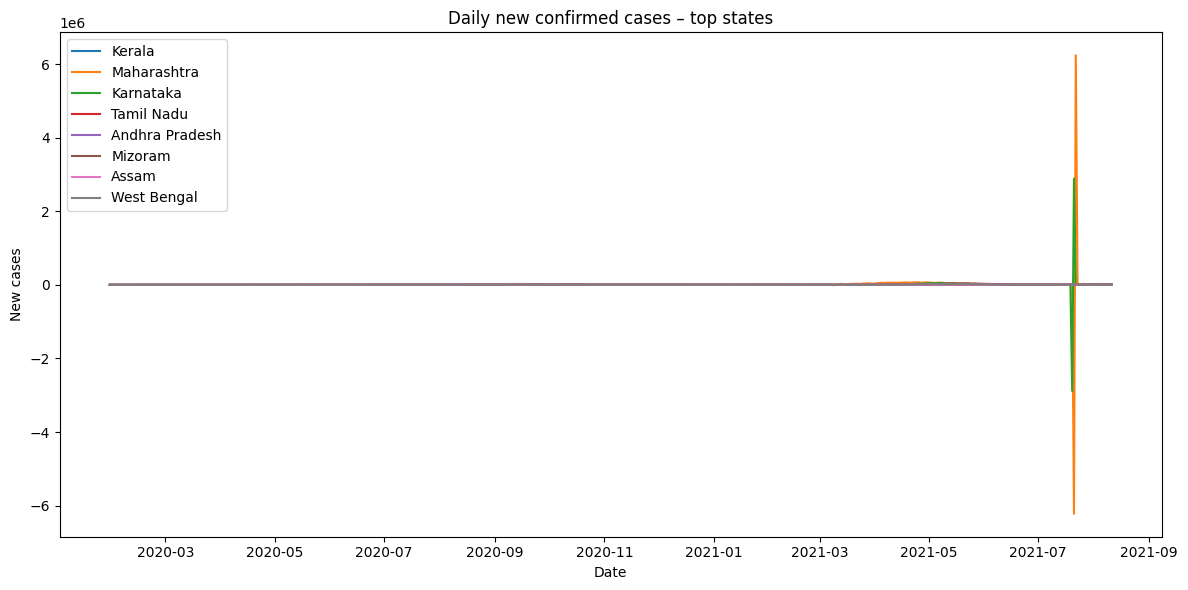

In [7]:
top_panel = panel[panel['state'].isin(top_states)]
plt.figure(figsize=(12,6))
for s in top_states:
    sub = top_panel[top_panel['state']==s]
    plt.plot(sub['Date'], sub['new_confirmed'], label=s)
plt.legend()
plt.title("Daily new confirmed cases – top states")
plt.xlabel("Date")
plt.ylabel("New cases")
plt.tight_layout()
plt.savefig(FIGS_DIR / "new_cases_top_states.png")
plt.show()


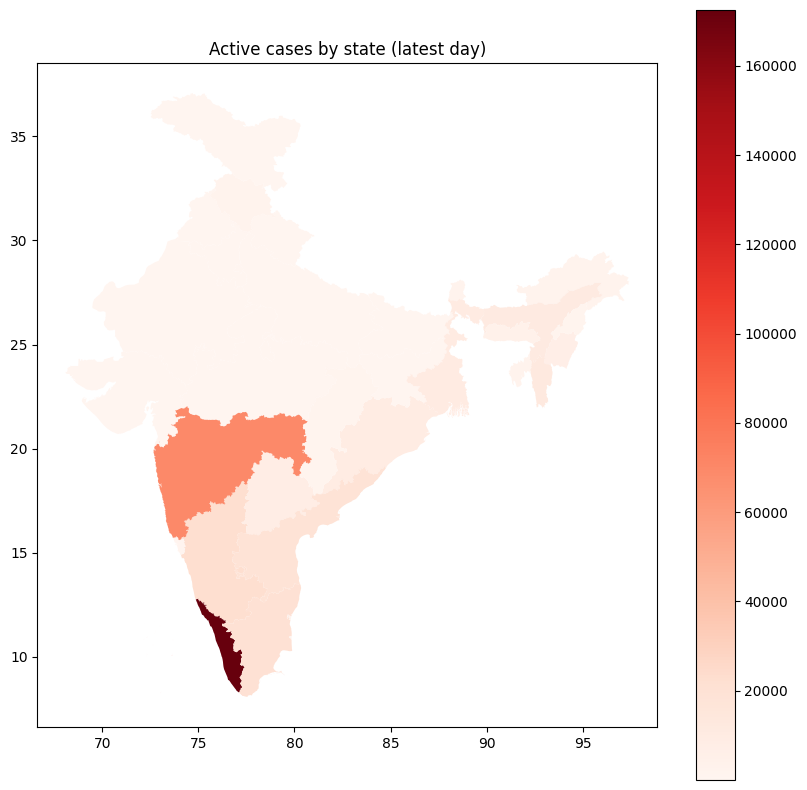

In [8]:
import geopandas as gpd
gdf = gpd.read_file(r"C:\Users\dedee\Downloads\epidemic-project\data_raw\shapefiles\india_states.shp")
latest_day = panel[panel['Date']==panel['Date'].max()]
map_df = gdf.merge(latest_day, left_on='ST_NM', right_on='state')
map_df.plot(column='active', cmap='Reds', legend=True, figsize=(10,10))
plt.title("Active cases by state (latest day)")
plt.show()
